# 03 — Run & Inspect Simulation

Run `llm_world_20` live (from the cached `world.json`) and inspect per-tier cash,
inventory value, equity composition, and P&L across **all** echelon tiers
(factory, shop, demand sinks) via `src/sim/inspect.py`.

The notebook reads the in-memory `run_log`; no parquet files are read.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
from dataclasses import replace
from datetime import datetime
from pathlib import Path

while not (Path.cwd() / 'pyproject.toml').exists():
    os.chdir('..')

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 80
plt.rcParams['savefig.dpi'] = 80

In [2]:
from src.sim.distributions import Constant, Uniform
from src.sim.inspect import global_timeseries_df, node_equity, node_timeseries_df
from src.sim.node import DemandSinkNode, FactoryNode, IntermediateNode
from src.sim.policy import DefaultDemandSinkPolicy, OrderUpToPolicy, StaticFactoryPolicy
from src.sim.runner import Runner, build_world
from src.sim.scenario import (
    DisruptionParams,
    ItemLifecycleParams,
    Scenario,
)
from src.sim.world import World, world_to_graph

## 1. Build scenario from cached world

Loads `data/worlds/fashion_retail_20/world.json` (committed to the repo) so no
LLM call or API key is required.  Replicates the `llm_world_20` topology:
one factory per product, one shop, 20 per-product demand sinks.

In [3]:
WORLD_PATH = Path('data/worlds/fashion_retail_20/world.json')
N_STEPS = 120
WORLD_SEED = 42
COVER_HORIZON_TICKS = 30

world = World.from_json(WORLD_PATH)

# Replicate llm_world_20 store template.
_base = next(iter(world.store_templates.values()))
template = replace(
    _base,
    id='flagship_20_0',
    capacity=400,
    init_balance=500_000.0,
    init_active_count=10,
    init_freshness='baseline',
    init_stock_pct=0.0,
    order_fee=10.0,
)
world = replace(world, store_templates={'flagship_20_0': template})
topology = world_to_graph(world, sink_density=1.0)

# Attach policies.
shop_idx = 0
for ni in topology['node_instances']:
    node = ni.node
    if isinstance(node, FactoryNode):
        ni.policy = StaticFactoryPolicy(
            capacity_per_tick=node.capacity_per_tick,
            unit_cost=node.unit_cost,
            # Base-stock target bounds factory inventory (4x capacity).
            target_inventory=4 * node.capacity_per_tick,
        )
    elif isinstance(node, IntermediateNode):
        ni.policy = OrderUpToPolicy(
            policy_seed=1000 + shop_idx,
            cover_horizon_ticks=COVER_HORIZON_TICKS,
        )
        shop_idx += 1
    elif isinstance(node, DemandSinkNode):
        ni.policy = DefaultDemandSinkPolicy()

_STAGES = ['introduction', 'growth', 'maturity', 'decline', 'dead']
scenario = Scenario.from_world(
    world,
    disruption=DisruptionParams(
        event_prob=0.03,
        types=['natural_disaster', 'economic_crisis', 'pandemic', 'political_unrest'],
        regions=world.market.regions,
        severity=Uniform(0.005, 0.02),
        duration=Uniform(5, 20),
    ),
    item_lifecycle=ItemLifecycleParams(
        stages=_STAGES,
        init_stage='maturity',
        default_stage_change_probs={
            'introduction': 0.004,
            'growth': 0.003,
            'maturity': 0.0005,
            'decline': 0.005,
            'dead': 0.0001,
        },
    ),
    nodes=topology['node_instances'],
    edges=topology['edges'],
    n_steps=N_STEPS,
    start_date=datetime(2024, 1, 1),
    world_seed=WORLD_SEED,
)
print(f'Scenario: {len(scenario.nodes)} nodes, {len(scenario.edges)} edges, '
      f'{scenario.n_steps} steps')

Scenario: 41 nodes, 40 edges, 120 steps


## 2. Run simulation

Returns a dict with `"ticks"` (one entry per tick), `"global"` (market series),
and `"n_steps"`.  All subsequent analysis reads from this in-memory dict.

In [4]:
run_log = Runner(scenario).run()
sim = build_world(scenario)  # provides echelon levels

print(f'Ran {run_log["n_steps"]} ticks.')
level_label = {0: 'Factory', 1: 'Shop', 2: 'Sinks'}
for node_id, lvl in sorted(sim.levels.items(), key=lambda kv: kv[1])[:6]:
    print(f'  {node_id}: level {lvl} ({level_label.get(lvl, lvl)})')

Ran 120 ticks.
  flagship_20_0-factory-P0010: level 0 (Factory)
  flagship_20_0-factory-P0017: level 0 (Factory)
  flagship_20_0-factory-P0012: level 0 (Factory)
  flagship_20_0-factory-P0016: level 0 (Factory)
  flagship_20_0-factory-P0001: level 0 (Factory)
  flagship_20_0-factory-P0000: level 0 (Factory)


## 3. Per-tier cash, inventory, and orders

Aggregate by echelon level. Level 0 = factory, 1 = shop, 2 = demand sinks.

In [5]:
df = node_timeseries_df(run_log, scenario)
# Enrich with echelon level from build_world (scenario.nodes carry level=None).
df['level'] = df['node_id'].map(sim.levels)

tier_df = (
    df.groupby(['tick', 'level'])[['cash', 'inventory_total', 'orders_total']]
    .sum()
    .reset_index()
)
tier_df.head(6)

,tick,level,cash,inventory_total,orders_total
0,1,0,-52400.0,3000,0
1,1,1,508620.0,305,0
2,1,2,5380.0,0,0
3,2,0,-102710.0,3905,0
4,2,1,510330.0,259,95
5,2,2,5580.0,0,0


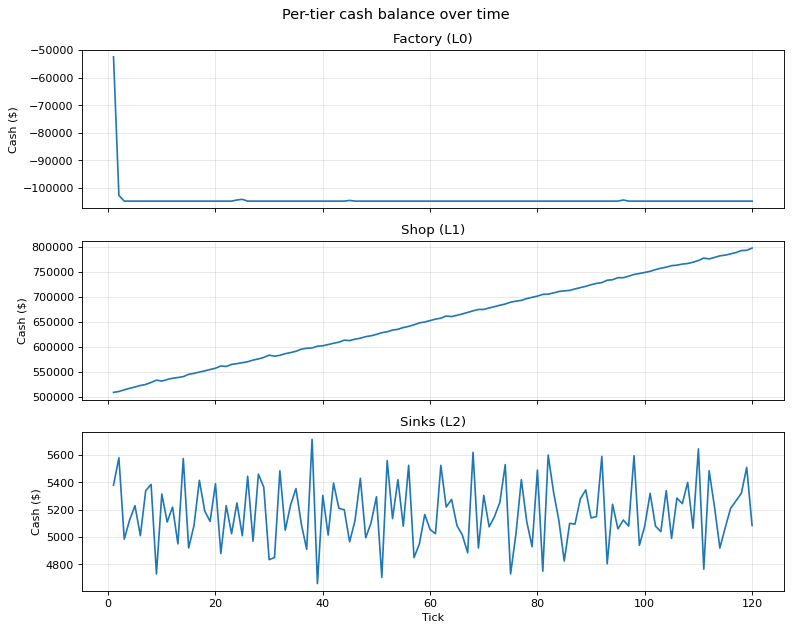

In [6]:
level_labels = {0: 'Factory (L0)', 1: 'Shop (L1)', 2: 'Sinks (L2)'}

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for ax, (level, grp) in zip(axes, tier_df.groupby('level')):
    ax.plot(grp['tick'], grp['cash'])
    ax.set_ylabel('Cash ($)')
    ax.set_title(level_labels.get(level, f'Level {level}'))
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Tick')
fig.suptitle('Per-tier cash balance over time', fontsize=13)
fig.tight_layout()
plt.show()

## 4. Per-tier inventory value

Inventory-at-cost per echelon tier across the run.

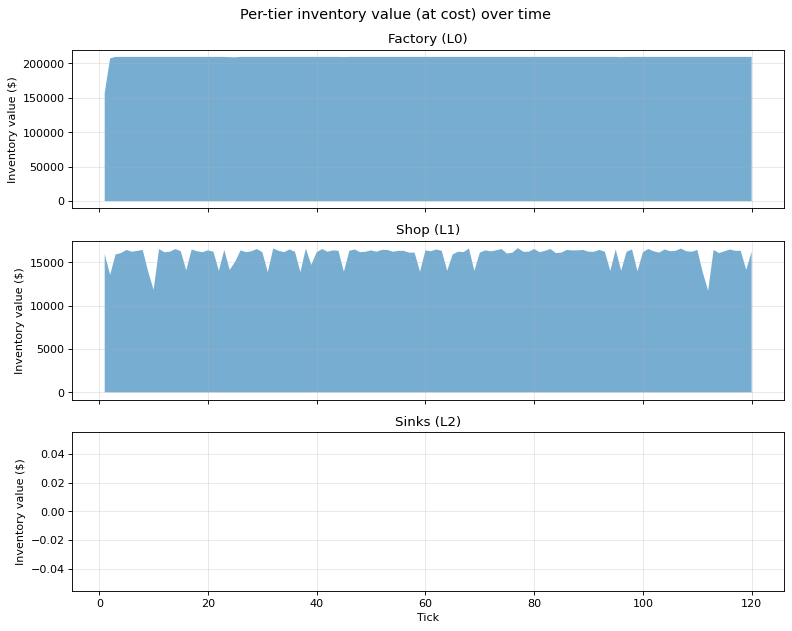

In [7]:
unit_cost = {w.product_id: float(w.unit_cost) for w in scenario.catalog}
avg_cost = sum(unit_cost.values()) / len(unit_cost) if unit_cost else 0.0

factory_unit_cost = {}
for ni in scenario.nodes:
    if isinstance(ni.node, FactoryNode):
        factory_unit_cost[ni.node.id] = float(ni.node.unit_cost)

def inv_value(row):
    if row['node_type'] == 'FactoryNode':
        return row['inventory_total'] * factory_unit_cost.get(row['node_id'], avg_cost)
    elif row['node_type'] == 'IntermediateNode':
        return row['inventory_total'] * avg_cost
    return 0.0

df['inv_value'] = df.apply(inv_value, axis=1)
tier_inv = df.groupby(['tick', 'level'])['inv_value'].sum().reset_index()

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for ax, (level, grp) in zip(axes, tier_inv.groupby('level')):
    ax.fill_between(grp['tick'], grp['inv_value'], alpha=0.6)
    ax.set_ylabel('Inventory value ($)')
    ax.set_title(level_labels.get(level, f'Level {level}'))
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Tick')
fig.suptitle('Per-tier inventory value (at cost) over time', fontsize=13)
fig.tight_layout()
plt.show()

## 5. Shop equity composition

For the shop (`IntermediateNode` at level 1), decompose equity into
cash, inventory-at-cost, and outstanding-order value across the run.

Shop: flagship_20_0-shop


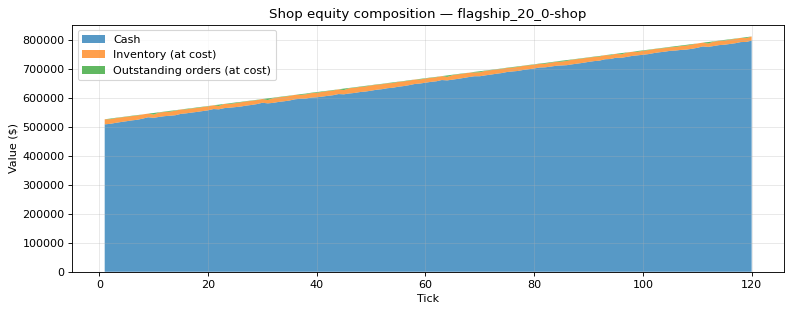

In [8]:
shop_ids = [ni.node.id for ni in scenario.nodes if isinstance(ni.node, IntermediateNode)]
shop_id = shop_ids[0]
print(f'Shop: {shop_id}')

shop_eq = node_equity(run_log, scenario, shop_id)

fig, ax = plt.subplots(figsize=(10, 4))
ax.stackplot(
    shop_eq['tick'],
    shop_eq['cash'],
    shop_eq['inventory_value'],
    shop_eq['outstanding_value'],
    labels=['Cash', 'Inventory (at cost)', 'Outstanding orders (at cost)'],
    alpha=0.75,
)
ax.set_xlabel('Tick')
ax.set_ylabel('Value ($)')
ax.set_title(f'Shop equity composition — {shop_id}')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

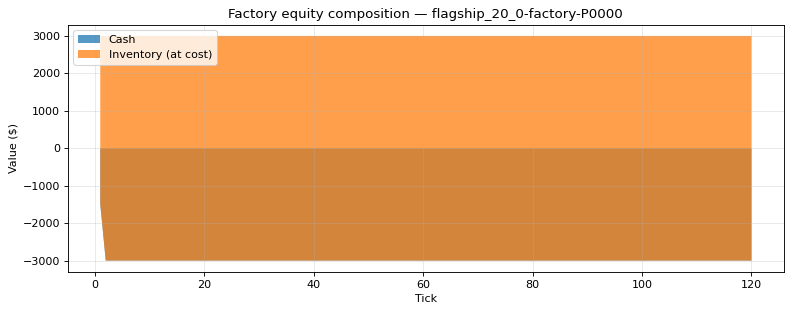

In [9]:
# Factory equity.
factory_id = [ni.node.id for ni in scenario.nodes if isinstance(ni.node, FactoryNode)][0]
fac_eq = node_equity(run_log, scenario, factory_id)

fig, ax = plt.subplots(figsize=(10, 4))
ax.stackplot(
    fac_eq['tick'],
    fac_eq['cash'],
    fac_eq['inventory_value'],
    labels=['Cash', 'Inventory (at cost)'],
    alpha=0.75,
)
ax.set_xlabel('Tick')
ax.set_ylabel('Value ($)')
ax.set_title(f'Factory equity composition — {factory_id}')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 6. System-level P&L

Total system cash = sum across all nodes. Growth reflects demand-sink income.

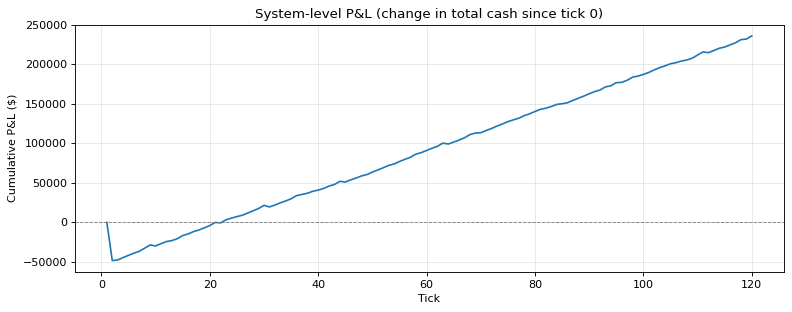

In [10]:
total_cash = df.groupby('tick')['cash'].sum().reset_index()
total_cash['pnl'] = total_cash['cash'] - total_cash['cash'].iloc[0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(total_cash['tick'], total_cash['pnl'])
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Tick')
ax.set_ylabel('Cumulative P&L ($)')
ax.set_title('System-level P&L (change in total cash since tick 0)')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 7. Global market supply / demand

Market supply and demand scalars per tick (from `global_timeseries_df`).

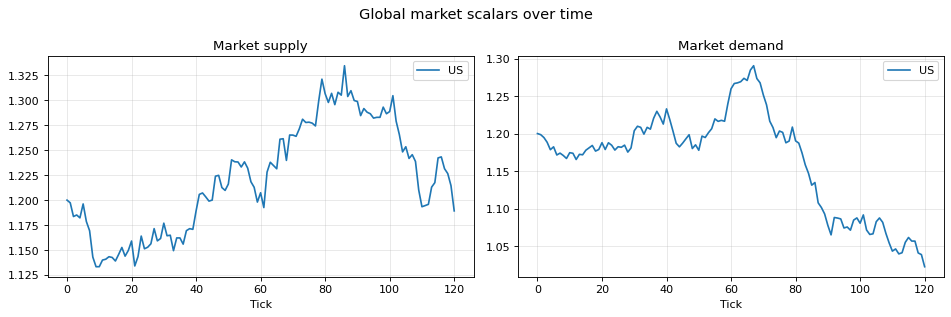

In [11]:
gdf = global_timeseries_df(run_log)
cols_supply = [c for c in gdf.columns if c.startswith('market_supply_')]
cols_demand = [c for c in gdf.columns if c.startswith('market_demand_')]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for col in cols_supply:
    axes[0].plot(gdf['tick'], gdf[col], label=col.replace('market_supply_', ''))
axes[0].set_title('Market supply')
axes[0].set_xlabel('Tick')
axes[0].legend()
axes[0].grid(alpha=0.3)

for col in cols_demand:
    axes[1].plot(gdf['tick'], gdf[col], label=col.replace('market_demand_', ''))
axes[1].set_title('Market demand')
axes[1].set_xlabel('Tick')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle('Global market scalars over time', fontsize=13)
fig.tight_layout()
plt.show()